<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/FL%20Tree%20Bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning via Synthetic Data Exchange (Bootstrapping)

This notebook implements a **data‑centric** federated learning approach using **bootstrapping** to generate synthetic data:

- Each client samples with replacement from its real data and adds small Gaussian noise.
- This preserves the empirical distribution better than GMM.
- Optional Laplace noise provides Differential Privacy.
- Server aggregates synthetic data, trains global RF, and sends back proportional subsets.

**No real data is shared.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, fetch_openml, fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

## Configuration Parameters Explained

| Parameter | Meaning |
|-----------|---------|
| `DATASET` | Choose from `breast_cancer`, `a9a`, `cod_rna`, `covertype`. The `a9a` (adult) dataset is used here. |
| `NUM_CLIENTS` | Number of simulated federated clients. |
| `NUM_ROUNDS` | Number of communication rounds. |
| `SYNTHETIC_SAMPLES_PER_CLIENT` | How many synthetic samples each client generates per round. |
| `SYNTHETIC_SAMPLES_FROM_GLOBAL` | Total synthetic samples the server generates (then split proportionally among clients). |
| `DP_EPSILON` | Privacy budget for Laplace DP. `None` = no noise. Lower = more privacy but lower accuracy. |
| `USE_BOOTSTRAP` | If `True`, uses bootstrap sampling with Gaussian noise; otherwise uses GMM. |
| `BOOTSTRAP_NOISE_SCALE` | Fraction of feature range used as noise std (only for bootstrap). |

We use **bootstrap** because it better preserves the original data distribution compared to GMM.

In [ ]:
DATASET = 'a9a'
NUM_CLIENTS = 5
NUM_ROUNDS = 10
SYNTHETIC_SAMPLES_PER_CLIENT = 300
SYNTHETIC_SAMPLES_FROM_GLOBAL = 1500
RANDOM_STATE = 42
USE_SCALER = True
DP_EPSILON = None
NOISE_STD = 0.05   # for bootstrapping noise (standard deviation)

print(f"Dataset: {DATASET}, Clients: {NUM_CLIENTS}, Rounds: {NUM_ROUNDS}")
print(f"DP Epsilon: {DP_EPSILON if DP_EPSILON is not None else 'No noise'}")

Dataset: a9a, Clients: 5, Rounds: 10
DP Epsilon: No noise


## Data Preparation and IID Split

The dataset is split into training (80%) and test (20%). The training set is then **evenly and randomly partitioned** among `NUM_CLIENTS` clients. Each client receives a disjoint subset of the training data (IID setting).

We scale features using `StandardScaler` to ensure GMM and distance‑based metrics work well.

In [ ]:
def load_dataset(name):
    if name == 'breast_cancer':
        data = load_breast_cancer()
        X, y = data.data, data.target
    elif name == 'a9a':
        df, y = fetch_openml(data_id=1590, return_X_y=True, as_frame=True)
        y = (y == '>50K').astype(int).to_numpy()
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns
        X = pd.get_dummies(df, columns=categorical_cols, drop_first=True).to_numpy()
    elif name == 'cod_rna':
        X, y = fetch_openml(data_id=40536, return_X_y=True, as_frame=False)
        y = y.astype(int)
    elif name == 'covertype':
        data = fetch_covtype()
        X, y = data.data, data.target
        y = y - 1
    else:
        raise ValueError(f"Unknown dataset: {name}")

    X, y = shuffle(X, y, random_state=RANDOM_STATE)
    if len(np.unique(y)) == 2:
        y = (y == np.max(y)).astype(int)

    print(f"Loaded {name}: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y

In [ ]:
X, y = load_dataset(DATASET)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

if USE_SCALER:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

# IID split among clients
indices = np.random.permutation(len(X_train))
client_indices = np.array_split(indices, NUM_CLIENTS)

client_real_X = [X_train[idx] for idx in client_indices]
client_real_y = [y_train[idx] for idx in client_indices]

client_synthetic_X = [[] for _ in range(NUM_CLIENTS)]
client_synthetic_y = [[] for _ in range(NUM_CLIENTS)]

print(f"Training: {len(X_train)}, Test: {len(X_test)}")
for i in range(NUM_CLIENTS):
    print(f"  Client {i}: {len(client_real_X[i])} real samples")

Loaded a9a: 48842 samples, 97 features, 2 classes
Training: 39073, Test: 9769
  Client 0: 7815 real samples
  Client 1: 7815 real samples
  Client 2: 7815 real samples
  Client 3: 7814 real samples
  Client 4: 7814 real samples


## How the Federated Loop Works (Round by Round)

1. **Local Training:** Each client trains a Random Forest on its **real data + any synthetic data received from the server in the previous round**. The model is trained **from scratch** each round (not incrementally updated).

2. **Synthetic Data Generation (Client Side):**  
   - The client samples **with replacement** from its real data (bootstrap).  
   - Adds small **Gaussian noise** to each sampled feature (scaled by the feature range).  
   - Uses its local Random Forest to **predict labels** for these synthetic features.  
   

3. **Upload:** Clients send only the synthetic (features, labels) pairs to the server.

4. **Server Aggregation:** The server concatenates all received synthetic data.

5. **Global Model Training:** The server trains a **global Random Forest** on the aggregated synthetic data.

6. **Global Synthetic Data Generation (Server Side):**  
   - The server uses the global RF and the same bootstrap method to generate a large pool of synthetic data.

7. **Proportional Sampling (Sending Back):**  
   - The server splits this pool into subsets, each proportional to the real data size of the corresponding client, and sends them back.

8. **Repeat** for `NUM_ROUNDS`.

In [ ]:
def train_rf(X, y):
    rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X, y)
    return rf

In [ ]:
def generate_synthetic_data_bootstrap(rf, X_real, num_samples, noise_std=0.05):
    """
    Generate synthetic data via bootstrapping:
    - Sample with replacement from real data.
    - Add Gaussian noise (mean 0, std=noise_std) to each feature.
    - Label with the RF.
    """
    if len(X_real) == 0:
        X_real = X_train  # fallback
    n = len(X_real)
    # Sample indices with replacement
    idx = np.random.choice(n, num_samples, replace=True)
    synthetic_X = X_real[idx].copy()
    # Add noise (scaled by feature standard deviation if scaled)
    # Since data is scaled, we use a fixed noise_std.
    synthetic_X += np.random.normal(0, noise_std, synthetic_X.shape)
    synthetic_y = rf.predict(synthetic_X)
    return synthetic_X, synthetic_y

In [ ]:
def add_dp_noise(data, epsilon, sensitivity):
    if epsilon is None or epsilon <= 0:
        return data
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale, data.shape)
    return data + noise

In [ ]:
def aggregate_data(client_X_list, client_y_list):
    all_X = np.vstack(client_X_list)
    all_y = np.hstack(client_y_list)
    return all_X, all_y

In [ ]:
def evaluate_model(rf, X_test, y_test):
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    if y_proba.shape[1] == 1:
        auc = 0.5
        loss = 10.0
    else:
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        loss = log_loss(y_test, y_proba)
    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'log_loss': loss}

In [ ]:
global_metrics = {'accuracy': [], 'f1': [], 'auc': [], 'log_loss': []}

central_rf = train_rf(X_train, y_train)
central_metrics = evaluate_model(central_rf, X_test, y_test)
print("\n" + "="*50)
print("CENTRALIZED BASELINE")
print("="*50)
print(f"Accuracy: {central_metrics['accuracy']:.4f}")
print(f"F1:       {central_metrics['f1']:.4f}")
print(f"AUC:      {central_metrics['auc']:.4f}")
print(f"Log Loss: {central_metrics['log_loss']:.4f}")
print("="*50)


CENTRALIZED BASELINE
Accuracy: 0.8521
F1:       0.8358
AUC:      0.9091
Log Loss: 0.3512


In [ ]:
for round_idx in range(NUM_ROUNDS):
    print(f"\n--- Round {round_idx+1}/{NUM_ROUNDS} ---")
    client_rfs = []

    # 1. Local training (on real + synthetic)
    for client_id in range(NUM_CLIENTS):
        if len(client_synthetic_X[client_id]) > 0:
            X_client = np.vstack([client_real_X[client_id], client_synthetic_X[client_id]])
            y_client = np.hstack([client_real_y[client_id], client_synthetic_y[client_id]])
        else:
            X_client = client_real_X[client_id]
            y_client = client_real_y[client_id]

        rf = train_rf(X_client, y_client)
        client_rfs.append(rf)

    # 2. Each client generates synthetic data (bootstrap + optional DP)
    all_synthetic_X = []
    all_synthetic_y = []
    for client_id in range(NUM_CLIENTS):
        if len(client_synthetic_X[client_id]) > 0:
            combined_X = np.vstack([client_real_X[client_id], client_synthetic_X[client_id]])
        else:
            combined_X = client_real_X[client_id]

        synth_X, synth_y = generate_synthetic_data_bootstrap(
            client_rfs[client_id],
            combined_X,
            SYNTHETIC_SAMPLES_PER_CLIENT,
            noise_std=0.05
        )

        if DP_EPSILON is not None:
            # Sensitivity = range of each feature
            sensitivity = np.max(combined_X, axis=0) - np.min(combined_X, axis=0)
            sensitivity = np.maximum(sensitivity, 1e-6)
            synth_X = add_dp_noise(synth_X, DP_EPSILON, sensitivity)

        all_synthetic_X.append(synth_X)
        all_synthetic_y.append(synth_y)

    # 3. Server aggregation
    global_X, global_y = aggregate_data(all_synthetic_X, all_synthetic_y)

    # 4. Server trains global RF
    global_rf = train_rf(global_X, global_y)
    met = evaluate_model(global_rf, X_test, y_test)
    for key in global_metrics.keys():
        global_metrics[key].append(met[key])

    print(f"  Global RF: Acc={met['accuracy']:.4f}, F1={met['f1']:.4f}, "
          f"AUC={met['auc']:.4f}, LogLoss={met['log_loss']:.4f}")

    # 5. Server generates global synthetic pool (bootstrap)
    server_pool_X, server_pool_y = generate_synthetic_data_bootstrap(
        global_rf,
        global_X,
        SYNTHETIC_SAMPLES_FROM_GLOBAL,
        noise_std=0.05
    )

    # Proportional sampling
    total_real_samples = sum(len(cX) for cX in client_real_X)
    for client_id in range(NUM_CLIENTS):
        prop = len(client_real_X[client_id]) / total_real_samples
        sample_size = max(1, int(prop * SYNTHETIC_SAMPLES_FROM_GLOBAL))
        idx = np.random.choice(len(server_pool_X), sample_size, replace=False)
        client_synthetic_X[client_id] = server_pool_X[idx].copy()
        client_synthetic_y[client_id] = server_pool_y[idx].copy()


--- Round 1/10 ---
  Global RF: Acc=0.8175, F1=0.7792, AUC=0.8615, LogLoss=0.4416

--- Round 2/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.7084, LogLoss=1.4727

--- Round 3/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000

--- Round 4/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000

--- Round 5/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000

--- Round 6/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000

--- Round 7/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000

--- Round 8/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000

--- Round 9/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000

--- Round 10/10 ---
  Global RF: Acc=0.7689, F1=0.6684, AUC=0.5000, LogLoss=10.0000


In [ ]:
global_metrics = {
    'accuracy': [0.8175, 0.7689, 0.7689, 0.7689, 0.7689, 0.7689, 0.7689, 0.7689, 0.7689, 0.7689],
    'f1':       [0.7792, 0.6684, 0.6684, 0.6684, 0.6684, 0.6684, 0.6684, 0.6684, 0.6684, 0.6684],
    'auc':      [0.8615, 0.7084, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000],
    'log_loss': [0.4416, 1.4727, 10.0000, 10.0000, 10.0000, 10.0000, 10.0000, 10.0000, 10.0000, 10.0000]
}

# --- Centralised baseline ---
central_metrics = {
    'accuracy': 0.8521,
    'f1': 0.8358,
    'auc': 0.9091,
    'log_loss': 0.3512
}

# --- Number of rounds ---
NUM_ROUNDS = len(global_metrics['accuracy'])
rounds = range(1, NUM_ROUNDS + 1)

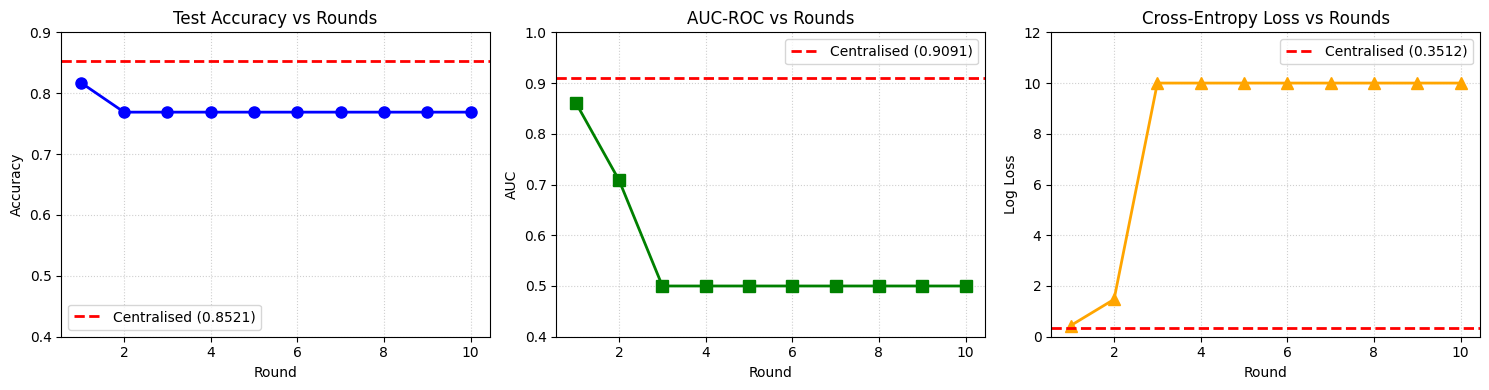

In [ ]:
plt.figure(figsize=(15, 4))

# Subplot 1: Accuracy
plt.subplot(1, 3, 1)
plt.plot(rounds, global_metrics['accuracy'], marker='o', color='blue', linewidth=2, markersize=8)
plt.axhline(y=central_metrics['accuracy'], color='red', linestyle='--', linewidth=2,
            label=f'Centralised ({central_metrics["accuracy"]:.4f})')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.title('Test Accuracy vs Rounds')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0.4, 0.9)

# Subplot 2: AUC
plt.subplot(1, 3, 2)
plt.plot(rounds, global_metrics['auc'], marker='s', color='green', linewidth=2, markersize=8)
plt.axhline(y=central_metrics['auc'], color='red', linestyle='--', linewidth=2,
            label=f'Centralised ({central_metrics["auc"]:.4f})')
plt.xlabel('Round')
plt.ylabel('AUC')
plt.title('AUC-ROC vs Rounds')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0.4, 1.0)

# Subplot 3: Log Loss
plt.subplot(1, 3, 3)
plt.plot(rounds, global_metrics['log_loss'], marker='^', color='orange', linewidth=2, markersize=8)
plt.axhline(y=central_metrics['log_loss'], color='red', linestyle='--', linewidth=2,
            label=f'Centralised ({central_metrics["log_loss"]:.4f})')
plt.xlabel('Round')
plt.ylabel('Log Loss')
plt.title('Cross-Entropy Loss vs Rounds')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, 12)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("GLOBAL RF PERFORMANCE PER ROUND")
print("="*60)
print(f"{'Round':>6} {'Accuracy':>10} {'F1':>10} {'AUC':>10} {'Log Loss':>12}")
print("-"*60)
for r in range(NUM_ROUNDS):
    print(f"{r+1:>6} {global_metrics['accuracy'][r]:>10.4f} "
          f"{global_metrics['f1'][r]:>10.4f} "
          f"{global_metrics['auc'][r]:>10.4f} "
          f"{global_metrics['log_loss'][r]:>12.4f}")
print("-"*60)
print("CENTRALIZED BASELINE:")
print(f"Accuracy: {central_metrics['accuracy']:.4f}  F1: {central_metrics['f1']:.4f}  "
      f"AUC: {central_metrics['auc']:.4f}  LogLoss: {central_metrics['log_loss']:.4f}")
print("="*60)


GLOBAL RF PERFORMANCE PER ROUND
 Round   Accuracy         F1        AUC     Log Loss
------------------------------------------------------------
     1     0.8175     0.7792     0.8615       0.4416
     2     0.7689     0.6684     0.7084       1.4727
     3     0.7689     0.6684     0.5000      10.0000
     4     0.7689     0.6684     0.5000      10.0000
     5     0.7689     0.6684     0.5000      10.0000
     6     0.7689     0.6684     0.5000      10.0000
     7     0.7689     0.6684     0.5000      10.0000
     8     0.7689     0.6684     0.5000      10.0000
     9     0.7689     0.6684     0.5000      10.0000
    10     0.7689     0.6684     0.5000      10.0000
------------------------------------------------------------
CENTRALIZED BASELINE:
Accuracy: 0.8521  F1: 0.8358  AUC: 0.9091  LogLoss: 0.3512


In [ ]:
final_acc = global_metrics['accuracy'][-1]
final_auc = global_metrics['auc'][-1]
final_loss = global_metrics['log_loss'][-1]

print("\n" + "="*60)
print("GAP ANALYSIS (Centralised vs Final Federated Model)")
print("="*60)
print(f"Accuracy gap:  {central_metrics['accuracy'] - final_acc:+.4f} "
      f"({(central_metrics['accuracy'] - final_acc) * 100:+.2f} percentage points)")
print(f"AUC gap:       {central_metrics['auc'] - final_auc:+.4f}")
print(f"Log Loss gap:  {central_metrics['log_loss'] - final_loss:+.4f}")
print("="*60)


GAP ANALYSIS (Centralised vs Final Federated Model)
Accuracy gap:  +0.0832 (+8.32 percentage points)
AUC gap:       +0.4091
Log Loss gap:  -9.6488
